# Cardiovascular Disease Prediction using PCG - CNN

Ce notebook utilise le dataset **PhysioNet/CinC Challenge 2016** pour classifier les signaux PCG en deux classes :

- `Abnormal`
- `Normal`

Le pipeline utilisé :

1. Télécharger les dossiers `training-a` à `training-f`
2. Charger les labels `REFERENCE.csv`
3. Transformer les fichiers `.wav` en Mel-spectrogrammes
4. Entraîner un CNN amélioré
5. Tester une architecture CNN plus forte
6. Optimiser le seuil de décision avec le Macro F1-score
7. Évaluer le modèle final
8. Tester une prédiction sur un fichier PCG


## 1. Installation des bibliothèques

In [ ]:
!pip install librosa soundfile scikit-learn tensorflow matplotlib pandas numpy

## 2. Importation des bibliothèques

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 3. Télécharger le dataset PhysioNet

Cette cellule télécharge les dossiers `training-a` à `training-f`.

Si tu les as déjà téléchargés dans Colab, tu peux ignorer cette cellule.


In [ ]:
import os

os.makedirs("/content/pcg_dataset", exist_ok=True)

!wget -r -N -c -np -P /content/pcg_dataset https://physionet.org/files/challenge-2016/1.0.0/training-a/
!wget -r -N -c -np -P /content/pcg_dataset https://physionet.org/files/challenge-2016/1.0.0/training-b/
!wget -r -N -c -np -P /content/pcg_dataset https://physionet.org/files/challenge-2016/1.0.0/training-c/
!wget -r -N -c -np -P /content/pcg_dataset https://physionet.org/files/challenge-2016/1.0.0/training-d/
!wget -r -N -c -np -P /content/pcg_dataset https://physionet.org/files/challenge-2016/1.0.0/training-e/
!wget -r -N -c -np -P /content/pcg_dataset https://physionet.org/files/challenge-2016/1.0.0/training-f/

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.

physionet.org/files 100%[===================>]      66  --.-KB/s    in 0s      

2026-05-17 16:35:58 (42.8 MB/s) - ‘/content/pcg_dataset/physionet.org/files/challenge-2016/1.0.0/training-e/e02011.hea’ saved [66/66]

--2026-05-17 16:35:58--  https://physionet.org/files/challenge-2016/1.0.0/training-e/e02011.wav
Reusing existing connection to physionet.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 88244 (86K) [text/plain]
Saving to: ‘/content/pcg_dataset/physionet.org/files/challenge-2016/1.0.0/training-e/e02011.wav’

physionet.org/files 100%[===================>]  86.18K   383KB/s    in 0.2s    

2026-05-17 16:35:59 (383 KB/s) - ‘/content/pcg_dataset/physionet.org/files/challenge-2016/1.0.0/training-e/e02011.wav’ saved [88244/88244]

--2026-05-17 16:35:59--  https://physionet.org/files/challenge-2016/1.0.0/training-e/e02012.hea
Reusing existing connection to physionet.org:443.
HTTP request s

## 4. Vérifier le chemin du dataset

In [ ]:
BASE_PATH = "/content/pcg_dataset/physionet.org/files/challenge-2016/1.0.0"

print("Dossiers disponibles :")
print(os.listdir(BASE_PATH))

Dossiers disponibles :
['training-c', 'training-b', 'training-e', 'training-f', 'training-d', 'training-a']


## 5. Charger tous les fichiers `REFERENCE.csv`

In [ ]:
training_folders = [
    "training-a",
    "training-b",
    "training-c",
    "training-d",
    "training-e",
    "training-f"
]

all_data = []

for folder in training_folders:
    folder_path = os.path.join(BASE_PATH, folder)
    reference_path = os.path.join(folder_path, "REFERENCE.csv")

    if os.path.exists(reference_path):
        ref_df = pd.read_csv(reference_path, header=None)
        ref_df.columns = ["filename", "label"]

        ref_df["folder"] = folder
        ref_df["file_path"] = ref_df["filename"].apply(
            lambda x: os.path.join(folder_path, x + ".wav")
        )

        all_data.append(ref_df)
        print(folder, "chargé :", len(ref_df), "fichiers")
    else:
        print("REFERENCE.csv introuvable dans :", folder_path)

labels_df = pd.concat(all_data, ignore_index=True)

# Dans ce dataset :
# 1  = Normal
# -1 = Abnormal
labels_df["label_binary"] = labels_df["label"].map({-1: 0, 1: 1})

labels_df["exists"] = labels_df["file_path"].apply(os.path.exists)
labels_df = labels_df[labels_df["exists"] == True].reset_index(drop=True)

print("\nNombre total de fichiers valides :", len(labels_df))
print("\nDistribution des classes :")
print(labels_df["label_binary"].value_counts())

labels_df.head()

training-a chargé : 409 fichiers
training-b chargé : 490 fichiers
training-c chargé : 31 fichiers
training-d chargé : 55 fichiers
training-e chargé : 2141 fichiers
training-f chargé : 114 fichiers

Nombre total de fichiers valides : 3240

Distribution des classes :
label_binary
0    2575
1     665
Name: count, dtype: int64


,filename,label,folder,file_path,label_binary,exists
0,a0001,1,training-a,/content/pcg_dataset/physionet.org/files/chall...,1,True
1,a0002,1,training-a,/content/pcg_dataset/physionet.org/files/chall...,1,True
2,a0003,1,training-a,/content/pcg_dataset/physionet.org/files/chall...,1,True
3,a0004,1,training-a,/content/pcg_dataset/physionet.org/files/chall...,1,True
4,a0005,1,training-a,/content/pcg_dataset/physionet.org/files/chall...,1,True


## 6. Visualiser la distribution des classes

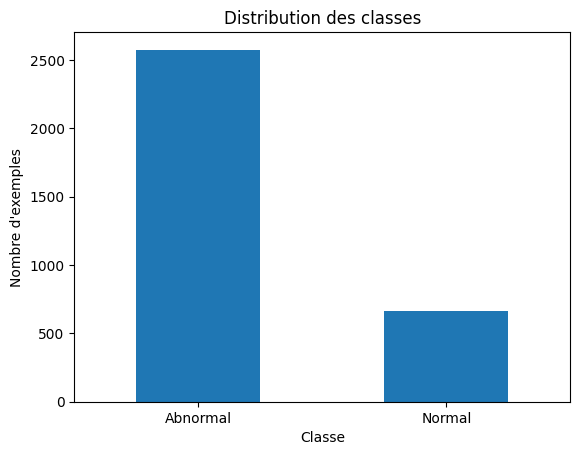

In [ ]:
labels_df["label_binary"].value_counts().plot(kind="bar")
plt.title("Distribution des classes")
plt.xlabel("Classe")
plt.ylabel("Nombre d'exemples")
plt.xticks([0, 1], ["Abnormal", "Normal"], rotation=0)
plt.show()

## 7. Fonction améliorée pour créer les Mel-spectrogrammes

Améliorations utilisées :

- Normalisation du signal audio
- `n_mels = 96`
- `hop_length = 128`
- Normalisation individuelle du Mel-spectrogramme


In [ ]:
def extract_mel_spectrogram_v2(file_path, max_duration=10, sr_target=2000, n_mels=96):
    try:
        signal, sr = librosa.load(file_path, sr=sr_target, duration=max_duration)

        target_length = sr_target * max_duration

        if len(signal) < target_length:
            signal = np.pad(signal, (0, target_length - len(signal)))
        else:
            signal = signal[:target_length]

        # Normalisation du signal audio
        max_amp = np.max(np.abs(signal))
        if max_amp > 0:
            signal = signal / max_amp

        mel_spec = librosa.feature.melspectrogram(
            y=signal,
            sr=sr_target,
            n_mels=n_mels,
            n_fft=512,
            hop_length=128
        )

        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Normalisation du spectrogramme
        mel_spec_db = (mel_spec_db - np.mean(mel_spec_db)) / (np.std(mel_spec_db) + 1e-8)

        return mel_spec_db

    except Exception as e:
        print("Erreur avec :", file_path)
        print(e)
        return None

## 8. Visualiser un exemple de signal et de Mel-spectrogramme

Fichier : /content/pcg_dataset/physionet.org/files/challenge-2016/1.0.0/training-a/a0001.wav
Sampling rate : 2000
Signal shape : (71332,)


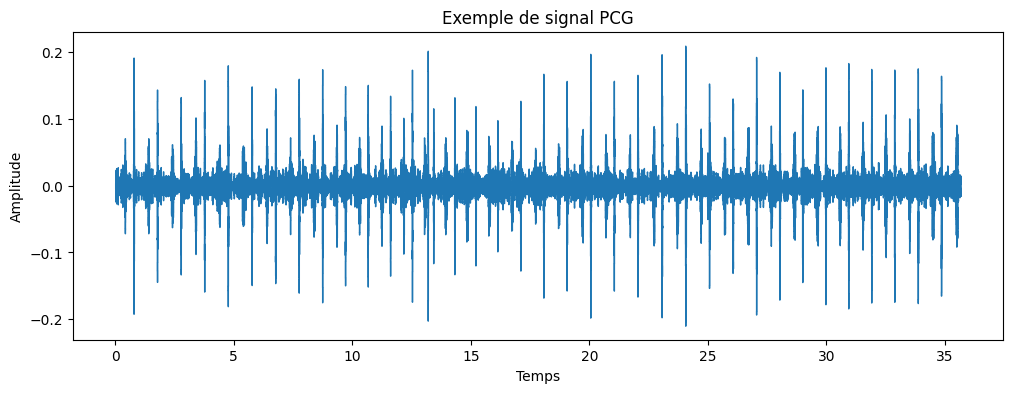

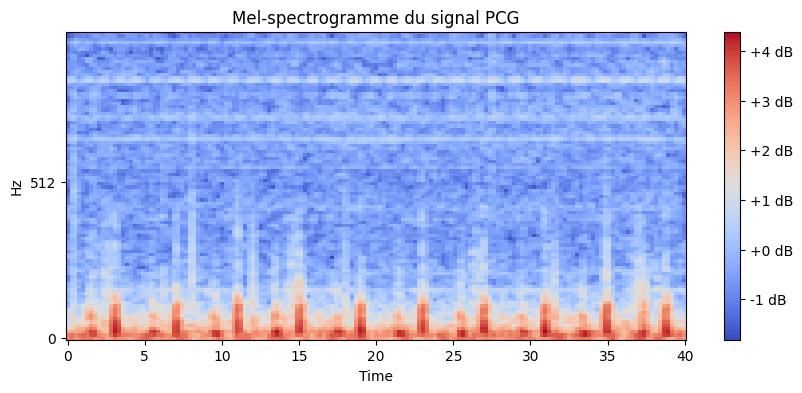

In [ ]:
example_path = labels_df.iloc[0]["file_path"]

signal, sr = librosa.load(example_path, sr=None)

print("Fichier :", example_path)
print("Sampling rate :", sr)
print("Signal shape :", signal.shape)

plt.figure(figsize=(12, 4))
librosa.display.waveshow(signal, sr=sr)
plt.title("Exemple de signal PCG")
plt.xlabel("Temps")
plt.ylabel("Amplitude")
plt.show()

mel_example = extract_mel_spectrogram_v2(example_path)

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    mel_example,
    sr=2000,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel-spectrogramme du signal PCG")
plt.show()

## 9. Construire le dataset CNN

Important : on utilise `sample()` et non `head()` pour éviter de prendre uniquement les premiers fichiers dans l'ordre.

On peux commencer avec :

```python
MAX_FILES = 1500
```

Puis augmenter à :

```python
MAX_FILES = 2000
MAX_FILES = len(labels_df)
```


In [ ]:
X = []
y = []

MAX_FILES = 1500

labels_sample = labels_df.sample(
    n=min(MAX_FILES, len(labels_df)),
    random_state=42
).reset_index(drop=True)

for index, row in labels_sample.iterrows():
    file_path = row["file_path"]

    mel_spec = extract_mel_spectrogram_v2(file_path)

    if mel_spec is not None:
        X.append(mel_spec)
        y.append(row["label_binary"])

X = np.array(X)
y = np.array(y)

print("Shape X avant reshape :", X.shape)
print("Shape y :", y.shape)
print("\nDistribution utilisée :")
print(pd.Series(y).value_counts())

Shape X avant reshape : (1500, 96, 157)
Shape y : (1500,)

Distribution utilisée :
0    1195
1     305
Name: count, dtype: int64


## 10. Reshape et normalisation

In [ ]:
# Ajouter le canal grayscale
X = X[..., np.newaxis]

# Normalisation globale
X = X / (np.max(np.abs(X)) + 1e-8)

print("Shape X après reshape :", X.shape)

Shape X après reshape : (1500, 96, 157, 1)


## 11. Division train/test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

print("\nDistribution train :")
print(pd.Series(y_train).value_counts())

print("\nDistribution test :")
print(pd.Series(y_test).value_counts())

Train : (1200, 96, 157, 1)
Test : (300, 96, 157, 1)

Distribution train :
0    956
1    244
Name: count, dtype: int64

Distribution test :
0    239
1     61
Name: count, dtype: int64


## 12. Calcul des poids de classes

Cela aide le modèle à gérer le déséquilibre entre les classes `Abnormal` et `Normal`.


In [ ]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = {
    int(classes[i]): class_weights[i]
    for i in range(len(classes))
}

print("Class weights :", class_weight_dict)

Class weights : {0: np.float64(0.6276150627615062), 1: np.float64(2.459016393442623)}


## 13. Callbacks d'entraînement

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

# Modèle 1 : CNN amélioré

Ce modèle est une bonne base avec :

- Conv2D
- BatchNormalization
- MaxPooling
- Dropout
- GlobalAveragePooling2D


In [ ]:
input_shape = X_train.shape[1:]

cnn_improved = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    Conv2D(256, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

cnn_improved.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_improved.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 155, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 94, 155, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 77, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 47, 77, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 45, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 22, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 35, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 35, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 15, 256)     │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 15, 256)     │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,785 (1.61 MB)

 Trainable params: 421,825 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

## 14. Entraîner le CNN amélioré

In [ ]:
history_improved = cnn_improved.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 30s 443ms/step - accuracy: 0.7042 - loss: 0.6161 - val_accuracy: 0.8000 - val_loss: 0.5064 - learning_rate: 5.0000e-04
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 440ms/step - accuracy: 0.7354 - loss: 0.4662 - val_accuracy: 0.8000 - val_loss: 0.6347 - learning_rate: 5.0000e-04
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 35s 583ms/step - accuracy: 0.7740 - loss: 0.3767 - val_accuracy: 0.8000 - val_loss: 0.8232 - learning_rate: 5.0000e-04
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 33s 553ms/step - accuracy: 0.7906 - loss: 0.3724 - val_accuracy: 0.8000 - val_loss: 1.4309 - learning_rate: 5.0000e-04
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 27s 445ms/step - accuracy: 0.7990 - loss: 0.3403 - val_accuracy: 0.8000 - val_loss: 1.3643 - learning_rate: 2.5000e-04
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 42s 459ms/step - accuracy: 0.8094 - loss: 0.3212 - val_accuracy: 0.8000 - val_loss: 1.0712 - learning_rate: 2.5000e-04
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 31s 515ms/step - acc

## 15. Courbes du CNN amélioré

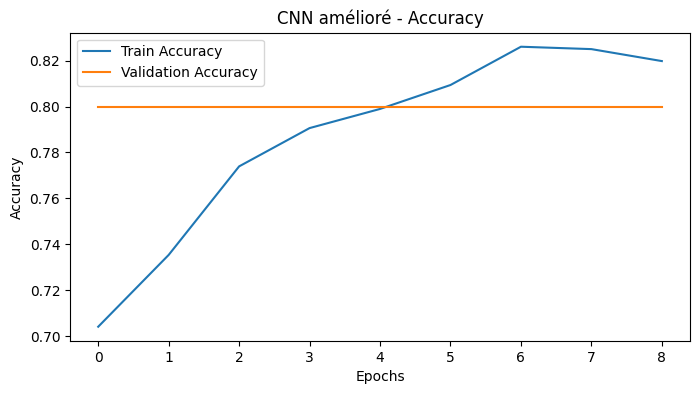

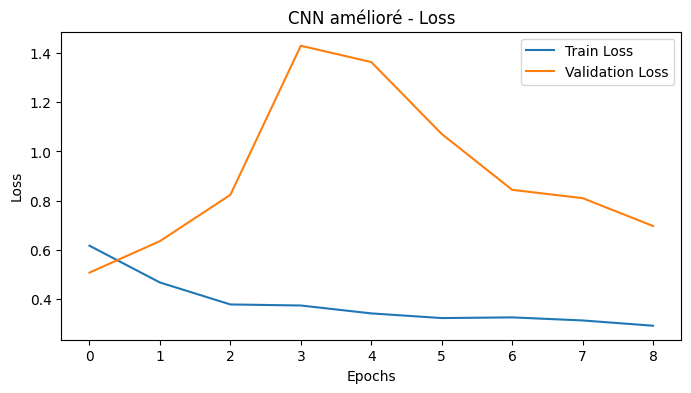

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history_improved.history["accuracy"], label="Train Accuracy")
plt.plot(history_improved.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN amélioré - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_improved.history["loss"], label="Train Loss")
plt.plot(history_improved.history["val_loss"], label="Validation Loss")
plt.title("CNN amélioré - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 16. Fonction d'optimisation du seuil

In [ ]:
def find_best_threshold(model, X_test, y_test):
    y_pred_prob = model.predict(X_test)

    best_threshold = 0
    best_f1 = 0
    best_acc = 0

    for threshold in np.arange(0.25, 0.75, 0.05):
        y_pred_temp = (y_pred_prob > threshold).astype(int).flatten()

        f1 = f1_score(y_test, y_pred_temp, average="macro")
        acc = accuracy_score(y_test, y_pred_temp)

        print(
            "Seuil :", round(threshold, 2),
            "| Accuracy :", round(acc, 3),
            "| Macro F1 :", round(f1, 3)
        )

        if f1 > best_f1:
            best_f1 = f1
            best_acc = acc
            best_threshold = threshold

    print("\nMeilleur seuil :", round(best_threshold, 2))
    print("Meilleure Accuracy :", round(best_acc, 3))
    print("Meilleur Macro F1 :", round(best_f1, 3))

    return best_threshold, y_pred_prob

## 17. Évaluation finale du CNN amélioré

In [ ]:
best_threshold_improved, y_pred_prob_improved = find_best_threshold(
    cnn_improved,
    X_test,
    y_test
)

y_pred_improved = (y_pred_prob_improved > best_threshold_improved).astype(int).flatten()

print("\nAccuracy finale CNN amélioré :", accuracy_score(y_test, y_pred_improved))

print("\nClassification Report final :")
print(classification_report(y_test, y_pred_improved, target_names=["Abnormal", "Normal"]))

print("\nConfusion Matrix finale :")
print(confusion_matrix(y_test, y_pred_improved))

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 193ms/step
Seuil : 0.25 | Accuracy : 0.67 | Macro F1 : 0.637
Seuil : 0.3 | Accuracy : 0.797 | Macro F1 : 0.443
Seuil : 0.35 | Accuracy : 0.797 | Macro F1 : 0.443
Seuil : 0.4 | Accuracy : 0.797 | Macro F1 : 0.443
Seuil : 0.45 | Accuracy : 0.797 | Macro F1 : 0.443
Seuil : 0.5 | Accuracy : 0.797 | Macro F1 : 0.443
Seuil : 0.55 | Accuracy : 0.797 | Macro F1 : 0.443
Seuil : 0.6 | Accuracy : 0.797 | Macro F1 : 0.443
Seuil : 0.65 | Accuracy : 0.797 | Macro F1 : 0.443
Seuil : 0.7 | Accuracy : 0.797 | Macro F1 : 0.443

Meilleur seuil : 0.25
Meilleure Accuracy : 0.67
Meilleur Macro F1 : 0.637

Accuracy finale CNN amélioré : 0.67

Classification Report final :
              precision    recall  f1-score   support

    Abnormal       0.96      0.61      0.75       239
      Normal       0.37      0.90      0.53        61

    accuracy                           0.67       300
   macro avg       0.67      0.76      0.64       300
weighted avg       0.84      0.67      0

# Modèle 2 : CNN strong

In [ ]:
cnn_strong = Sequential([
    Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.40),

    Conv2D(256, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.45),

    GlobalAveragePooling2D(),

    Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.50),

    Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.40),

    Dense(1, activation="sigmoid")
])

cnn_strong.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn_strong.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 96, 157, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 96, 157, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 96, 157, 32)    │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 96, 157, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 48, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 48, 78, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 48, 78, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 48, 78, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 48, 78, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 24, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 39, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 24, 39, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 24, 39, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 24, 39, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 12, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 19, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 12, 19, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 625,633 (2.39 MB)

 Trainable params: 624,225 (2.38 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 18. Entraîner le CNN strong

In [23]:
history_strong = cnn_strong.fit(
    X_train,
    y_train,
    epochs=60,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8219 - loss: 0.5348 - val_accuracy: 0.8000 - val_loss: 1.0952 - learning_rate: 3.1250e-05
Epoch 2/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.8375 - loss: 0.5083 - val_accuracy: 0.8000 - val_loss: 1.0344 - learning_rate: 3.1250e-05
Epoch 3/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 124s 2s/step - accuracy: 0.8260 - loss: 0.5326 - val_accuracy: 0.8000 - val_loss: 0.9457 - learning_rate: 3.1250e-05
Epoch 4/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.8469 - loss: 0.5210 - val_accuracy: 0.8000 - val_loss: 0.6885 - learning_rate: 1.5625e-05
Epoch 5/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.8458 - loss: 0.5072 - val_accuracy: 0.8042 - val_loss: 0.5874 - learning_rate: 1.5625e-05
Epoch 6/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.8417 - loss: 0.5116 - val_accuracy: 0.8458 - val_loss: 0.5152 - learning_rate: 1.5625e-05
Epoch 7/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.8458 

## 19. Courbes du CNN strong

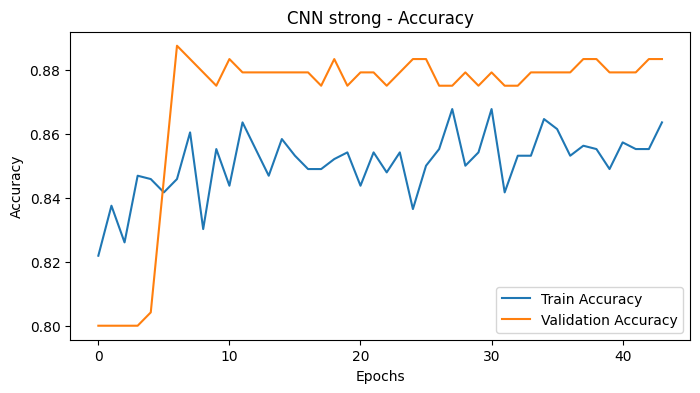

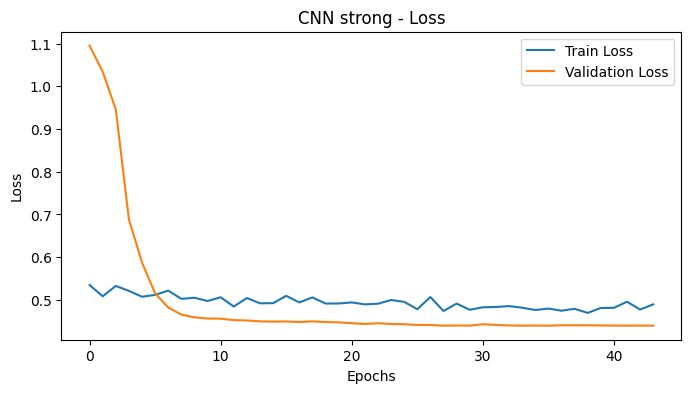

In [24]:
plt.figure(figsize=(8, 4))
plt.plot(history_strong.history["accuracy"], label="Train Accuracy")
plt.plot(history_strong.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN strong - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_strong.history["loss"], label="Train Loss")
plt.plot(history_strong.history["val_loss"], label="Validation Loss")
plt.title("CNN strong - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 20. Évaluation finale du CNN strong

In [25]:
best_threshold_strong, y_pred_prob_strong = find_best_threshold(
    cnn_strong,
    X_test,
    y_test
)

y_pred_strong = (y_pred_prob_strong > best_threshold_strong).astype(int).flatten()

print("\nAccuracy finale CNN strong :", accuracy_score(y_test, y_pred_strong))

print("\nClassification Report final :")
print(classification_report(y_test, y_pred_strong, target_names=["Abnormal", "Normal"]))

print("\nConfusion Matrix finale :")
print(confusion_matrix(y_test, y_pred_strong))

10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 645ms/step
Seuil : 0.25 | Accuracy : 0.853 | Macro F1 : 0.804
Seuil : 0.3 | Accuracy : 0.88 | Macro F1 : 0.827
Seuil : 0.35 | Accuracy : 0.9 | Macro F1 : 0.84
Seuil : 0.4 | Accuracy : 0.897 | Macro F1 : 0.821
Seuil : 0.45 | Accuracy : 0.883 | Macro F1 : 0.792
Seuil : 0.5 | Accuracy : 0.887 | Macro F1 : 0.786
Seuil : 0.55 | Accuracy : 0.883 | Macro F1 : 0.773
Seuil : 0.6 | Accuracy : 0.877 | Macro F1 : 0.751
Seuil : 0.65 | Accuracy : 0.863 | Macro F1 : 0.707
Seuil : 0.7 | Accuracy : 0.857 | Macro F1 : 0.687

Meilleur seuil : 0.35
Meilleure Accuracy : 0.9
Meilleur Macro F1 : 0.84

Accuracy finale CNN strong : 0.9

Classification Report final :
              precision    recall  f1-score   support

    Abnormal       0.93      0.95      0.94       239
      Normal       0.78      0.70      0.74        61

    accuracy                           0.90       300
   macro avg       0.85      0.83      0.84       300
weighted avg       0.90      0.90      0.90     

## 21. Comparaison des deux modèles

In [26]:
acc_improved = accuracy_score(y_test, y_pred_improved)
f1_improved = f1_score(y_test, y_pred_improved, average="macro")

acc_strong = accuracy_score(y_test, y_pred_strong)
f1_strong = f1_score(y_test, y_pred_strong, average="macro")

results = pd.DataFrame({
    "Model": ["CNN amélioré", "CNN strong"],
    "Best threshold": [best_threshold_improved, best_threshold_strong],
    "Accuracy": [acc_improved, acc_strong],
    "Macro F1": [f1_improved, f1_strong]
})

results

,Model,Best threshold,Accuracy,Macro F1
0,CNN amélioré,0.25,0.67,0.636559
1,CNN strong,0.35,0.90,0.839698


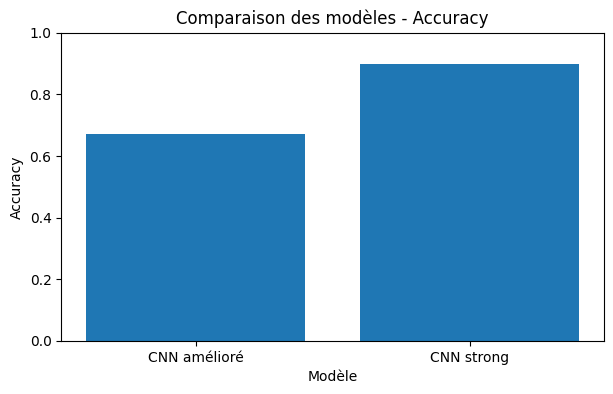

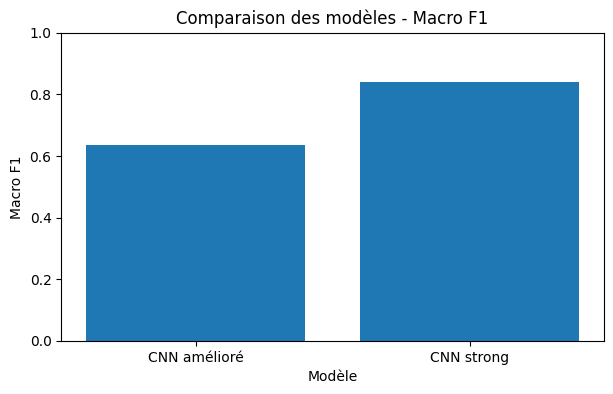

In [27]:
plt.figure(figsize=(7, 4))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Comparaison des modèles - Accuracy")
plt.xlabel("Modèle")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(results["Model"], results["Macro F1"])
plt.title("Comparaison des modèles - Macro F1")
plt.xlabel("Modèle")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.show()

## 22. Choisir automatiquement le meilleur modèle

In [28]:
if f1_strong >= f1_improved:
    best_model = cnn_strong
    best_model_name = "CNN strong"
    best_threshold = best_threshold_strong
    y_pred_final = y_pred_strong
else:
    best_model = cnn_improved
    best_model_name = "CNN amélioré"
    best_threshold = best_threshold_improved
    y_pred_final = y_pred_improved

print("Meilleur modèle :", best_model_name)
print("Meilleur seuil :", round(best_threshold, 2))
print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Macro F1 :", f1_score(y_test, y_pred_final, average="macro"))

Meilleur modèle : CNN strong
Meilleur seuil : 0.35
Accuracy : 0.9
Macro F1 : 0.8396979196352237


## 23. Matrice de confusion finale

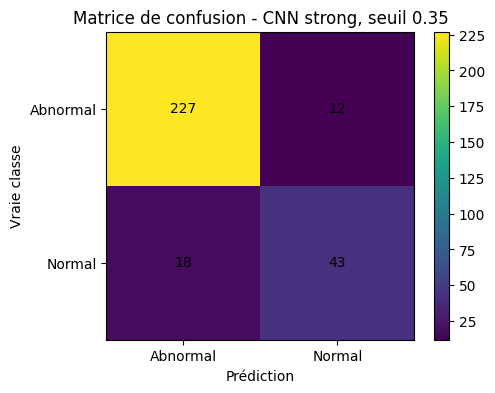

In [29]:
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title(f"Matrice de confusion - {best_model_name}, seuil {round(best_threshold, 2)}")
plt.xlabel("Prédiction")
plt.ylabel("Vraie classe")
plt.xticks([0, 1], ["Abnormal", "Normal"])
plt.yticks([0, 1], ["Abnormal", "Normal"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

## 24. Tester une prédiction sur un fichier PCG

In [30]:
def predict_one_pcg(file_path, model, threshold):
    mel_spec = extract_mel_spectrogram_v2(file_path)

    if mel_spec is None:
        return None

    mel_spec = mel_spec[np.newaxis, ..., np.newaxis]
    mel_spec = mel_spec / (np.max(np.abs(mel_spec)) + 1e-8)

    prob = model.predict(mel_spec)[0][0]
    pred_class = 1 if prob > threshold else 0

    pred_label = "Normal" if pred_class == 1 else "Abnormal"

    return pred_label, prob

In [31]:
idx = 10

test_file = labels_sample.iloc[idx]["file_path"]
true_class = labels_sample.iloc[idx]["label_binary"]
true_label = "Normal" if true_class == 1 else "Abnormal"

prediction, probability = predict_one_pcg(
    test_file,
    model=best_model,
    threshold=best_threshold
)

print("Fichier testé :", test_file)
print("Vraie classe :", true_label)
print("Prédiction du modèle :", prediction)
print("Probabilité Normal :", probability)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Fichier testé : /content/pcg_dataset/physionet.org/files/challenge-2016/1.0.0/training-a/a0230.wav
Vraie classe : Normal
Prédiction du modèle : Normal
Probabilité Normal : 0.99889714


## 25. Tester un fichier au hasard

In [32]:
import random

idx = random.randint(0, len(labels_sample) - 1)

test_file = labels_sample.iloc[idx]["file_path"]
true_class = labels_sample.iloc[idx]["label_binary"]
true_label = "Normal" if true_class == 1 else "Abnormal"

prediction, probability = predict_one_pcg(
    test_file,
    model=best_model,
    threshold=best_threshold
)

print("Fichier testé :", test_file)
print("Vraie classe :", true_label)
print("Prédiction du modèle :", prediction)
print("Probabilité Normal :", probability)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Fichier testé : /content/pcg_dataset/physionet.org/files/challenge-2016/1.0.0/training-a/a0110.wav
Vraie classe : Normal
Prédiction du modèle : Normal
Probabilité Normal : 0.99995065


## 26. Sauvegarder le meilleur modèle

In [33]:
best_model.save("best_cnn_pcg_model.h5")

with open("best_threshold.txt", "w") as f:
    f.write(str(best_threshold))

print("Modèle sauvegardé : best_cnn_pcg_model.h5")
print("Seuil sauvegardé : best_threshold.txt")

Modèle sauvegardé : best_cnn_pcg_model.h5
Seuil sauvegardé : best_threshold.txt


## 27. Télécharger le modèle

In [34]:
from google.colab import files

files.download("best_cnn_pcg_model.h5")
files.download("best_threshold.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

Dans ce notebook, nous avons amélioré le modèle CNN en appliquant :

1. Mélange des données avec `sample()` au lieu de `head()`
2. Normalisation du signal audio
3. Mel-spectrogramme amélioré
4. Normalisation individuelle des spectrogrammes
5. Utilisation de `class_weight`
6. Test de deux architectures CNN
7. Optimisation automatique du seuil avec le Macro F1-score

Le meilleur modèle est choisi automatiquement selon le **Macro F1-score**, car cette métrique est plus adaptée qu'une simple accuracy lorsque les classes sont déséquilibrées.
